# Tree-Based Methods: Decision Tree, Random Forest, GBM & XGBoost

This notebook covers four major tree-based methods for classification:
1. **Decision Tree** — simple, interpretable baseline
2. **Random Forest** — bagging ensemble of trees
3. **Gradient Boosting Machine (GBM)** — sequential boosting
4. **XGBoost** — optimized gradient boosting

We will compare their performance on two datasets:
- **Breast Cancer Wisconsin** (binary classification, 30 features)
- **Iris** (multi-class classification, 3 classes)


---
## Setup: Import Libraries

In [1]:
# Core libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_breast_cancer, load_iris
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# XGBoost
import xgboost as xgb

print("All libraries imported successfully")

All libraries imported successfully


---
## Part 1: Binary Classification — Breast Cancer Dataset

Load the Breast Cancer dataset and split into training/test sets.

In [2]:
# Load Breast Cancer dataset
data = load_breast_cancer()
X = data.data
y = data.target

print("Number of samples:", X.shape[0])
print("Number of features:", X.shape[1])
print("Feature names:", data.feature_names)
print("Target names:", data.target_names)
print("Target distribution:", np.bincount(y))
print("Classes: 0 = malignant, 1 = benign")

Number of samples: 569
Number of features: 30
Feature names: ['mean radius' 'mean texture' 'mean perimeter' 'mean area'
 'mean smoothness' 'mean compactness' 'mean concavity'
 'mean concave points' 'mean symmetry' 'mean fractal dimension'
 'radius error' 'texture error' 'perimeter error' 'area error'
 'smoothness error' 'compactness error' 'concavity error'
 'concave points error' 'symmetry error' 'fractal dimension error'
 'worst radius' 'worst texture' 'worst perimeter' 'worst area'
 'worst smoothness' 'worst compactness' 'worst concavity'
 'worst concave points' 'worst symmetry' 'worst fractal dimension']
Target names: ['malignant' 'benign']
Target distribution: [212 357]
Classes: 0 = malignant, 1 = benign


In [3]:
# Split into train/test sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training set size: {X_train.shape[0]} samples")
print(f"Test set size: {X_test.shape[0]} samples")

Training set size: 455 samples
Test set size: 114 samples


---
### 1. Decision Tree
A single decision tree with `max_depth=3` for interpretability. We'll visualize the tree structure and evaluate performance.

Decision Tree Accuracy: 93.86%

Classification Report:
              precision    recall  f1-score   support

   malignant       0.93      0.90      0.92        42
      benign       0.95      0.96      0.95        72

    accuracy                           0.94       114
   macro avg       0.94      0.93      0.93       114
weighted avg       0.94      0.94      0.94       114



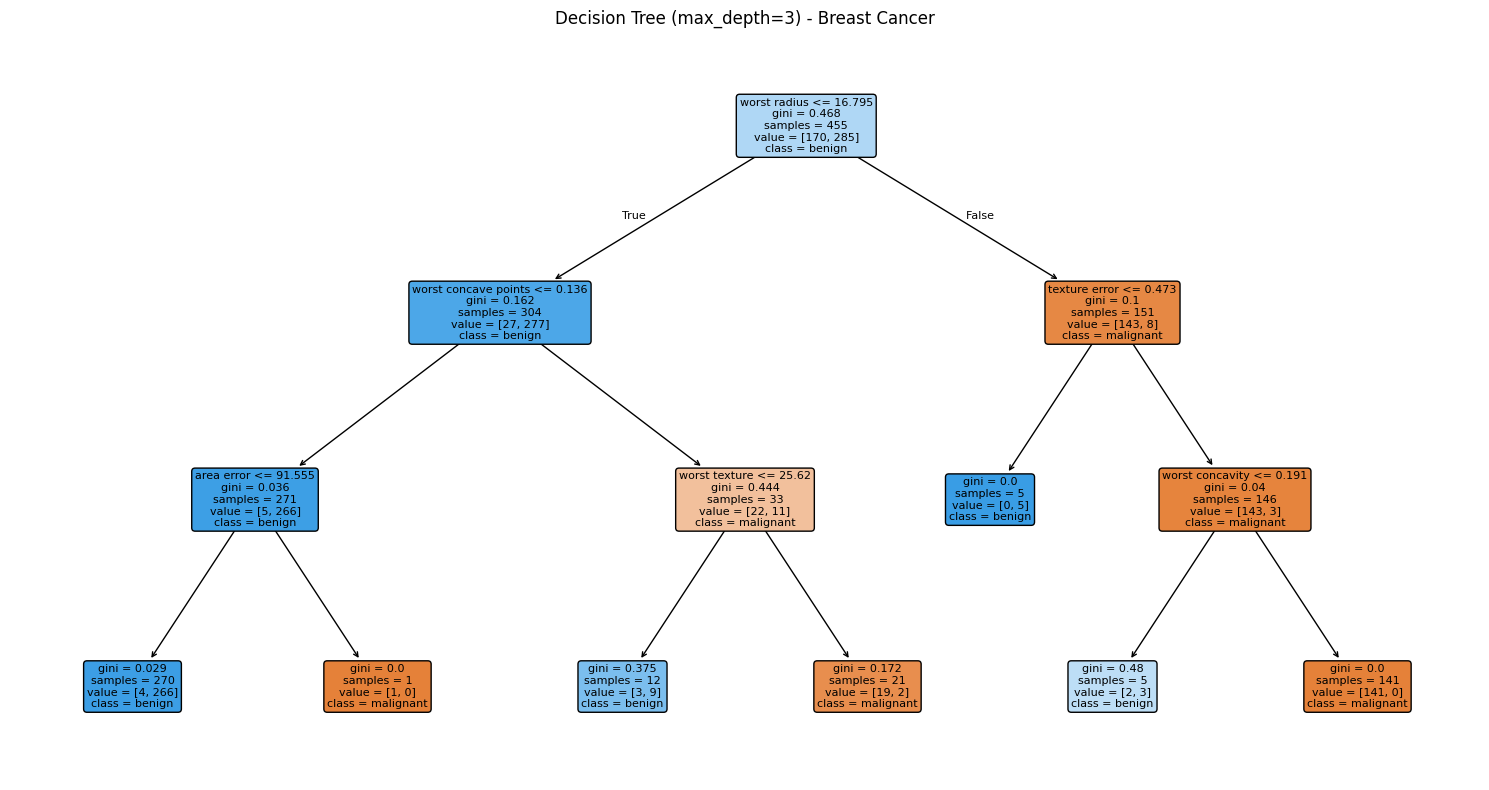

In [4]:
# --- Decision Tree ---
dt = DecisionTreeClassifier(max_depth=3, random_state=42)
dt.fit(X_train, y_train)
y_pred_dt = dt.predict(X_test)

acc_dt = accuracy_score(y_test, y_pred_dt)
print(f"Decision Tree Accuracy: {acc_dt * 100:.2f}%")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_dt, target_names=data.target_names))

# Plot the decision tree
plt.figure(figsize=(15, 8))
plot_tree(dt, filled=True, feature_names=data.feature_names, 
          class_names=data.target_names, rounded=True, fontsize=8)
plt.title("Decision Tree (max_depth=3) - Breast Cancer")
plt.tight_layout()
plt.show()

---
### 2. Random Forest
An ensemble of 100 decision trees trained on bootstrapped samples. We'll also look at feature importance.

Random Forest Accuracy: 95.61%

Classification Report:
              precision    recall  f1-score   support

   malignant       0.95      0.93      0.94        42
      benign       0.96      0.97      0.97        72

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114



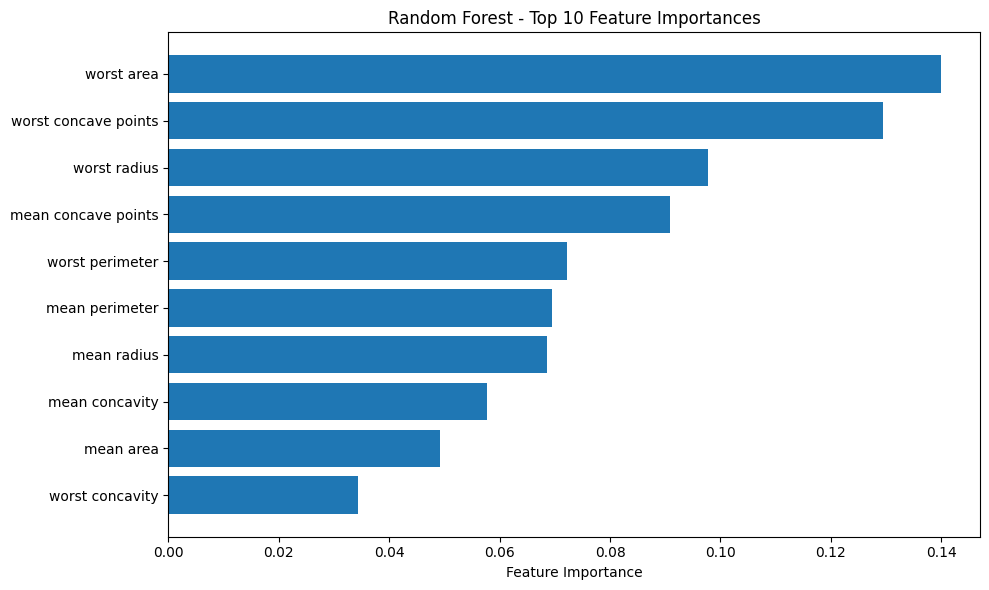

In [5]:
# --- Random Forest ---
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

acc_rf = accuracy_score(y_test, y_pred_rf)
print(f"Random Forest Accuracy: {acc_rf * 100:.2f}%")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf, target_names=data.target_names))

# Feature importance
importances = rf.feature_importances_
indices = np.argsort(importances)[-10:]

plt.figure(figsize=(10, 6))
plt.barh(range(len(indices)), importances[indices], align='center')
plt.yticks(range(len(indices)), [data.feature_names[i] for i in indices])
plt.xlabel("Feature Importance")
plt.title("Random Forest - Top 10 Feature Importances")
plt.tight_layout()
plt.show()

---
### 3. Gradient Boosting Machine (GBM)
Builds trees sequentially, each correcting the errors of the previous one.

Gradient Boosting Accuracy: 95.61%

Classification Report:
              precision    recall  f1-score   support

   malignant       0.97      0.90      0.94        42
      benign       0.95      0.99      0.97        72

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114

Confusion Matrix:
[[38  4]
 [ 1 71]]


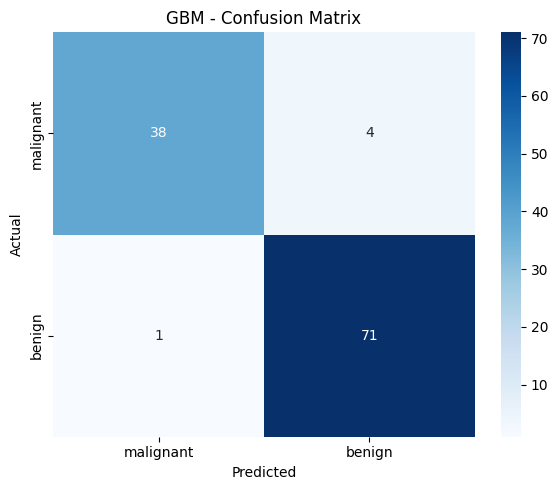

In [6]:
# --- Gradient Boosting Machine (GBM) ---
gbm = GradientBoostingClassifier(
    n_estimators=100, learning_rate=0.1, max_depth=3, random_state=42
)
gbm.fit(X_train, y_train)
y_pred_gbm = gbm.predict(X_test)

acc_gbm = accuracy_score(y_test, y_pred_gbm)
print(f"Gradient Boosting Accuracy: {acc_gbm * 100:.2f}%")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_gbm, target_names=data.target_names))
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_gbm))

# Plot confusion matrix
plt.figure(figsize=(6, 5))
sns.heatmap(confusion_matrix(y_test, y_pred_gbm), annot=True, fmt='d', cmap='Blues',
            xticklabels=data.target_names, yticklabels=data.target_names)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("GBM - Confusion Matrix")
plt.tight_layout()
plt.show()

---
### 4. Model Comparison (Breast Cancer)

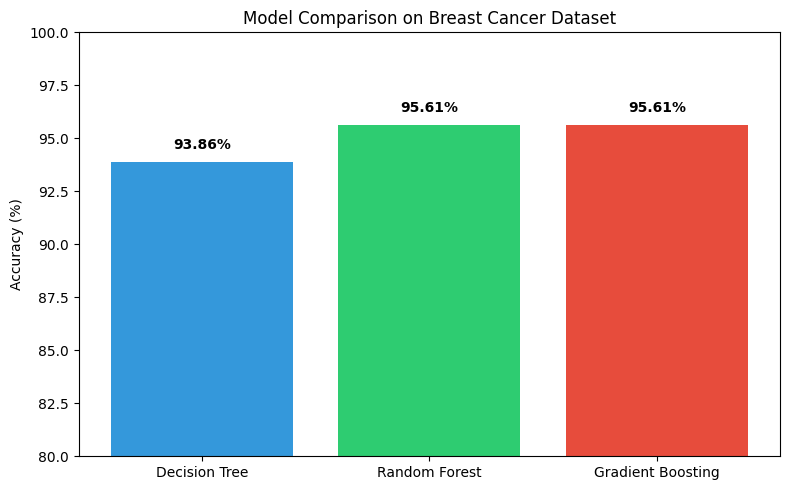


Summary:
            Model Accuracy
    Decision Tree   93.86%
    Random Forest   95.61%
Gradient Boosting   95.61%


In [7]:
# --- Model Comparison on Breast Cancer ---
models = ['Decision Tree', 'Random Forest', 'Gradient Boosting']
accuracies = [acc_dt, acc_rf, acc_gbm]

plt.figure(figsize=(8, 5))
bars = plt.bar(models, [a * 100 for a in accuracies], color=['#3498db', '#2ecc71', '#e74c3c'])
plt.ylabel("Accuracy (%)")
plt.title("Model Comparison on Breast Cancer Dataset")
plt.ylim(80, 100)

for bar, acc in zip(bars, accuracies):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
             f'{acc*100:.2f}%', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

comparison_df = pd.DataFrame({
    'Model': models,
    'Accuracy': [f'{a*100:.2f}%' for a in accuracies]
})
print("\nSummary:")
print(comparison_df.to_string(index=False))

---
## Part 2: Multi-class Classification — Iris Dataset
Now let's compare all four methods on the Iris dataset (3 flower species).

In [8]:
# ===== Multi-class Classification with Iris Dataset =====
iris = load_iris()
X_i = iris.data
y_i = iris.target

print("Number of samples:", X_i.shape[0])
print("Number of features:", X_i.shape[1])
print("Feature names:", iris.feature_names)
print("Target names:", iris.target_names)
print("Target distribution:", np.bincount(y_i))

# Split
X_tr_i, X_te_i, y_tr_i, y_te_i = train_test_split(
    X_i, y_i, test_size=0.2, random_state=42, stratify=y_i
)
print(f"\nTraining set size: {X_tr_i.shape[0]} samples")
print(f"Test set size: {X_te_i.shape[0]} samples")

Number of samples: 150
Number of features: 4
Feature names: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
Target names: ['setosa' 'versicolor' 'virginica']
Target distribution: [50 50 50]

Training set size: 120 samples
Test set size: 30 samples


---
### 5. XGBoost on Iris
XGBoost is configured for multi-class classification using `multi:softmax` objective.

In [9]:
# --- XGBoost on Iris (Multi-class) ---
dtrain = xgb.DMatrix(X_tr_i, label=y_tr_i)
dtest = xgb.DMatrix(X_te_i, label=y_te_i)

params = {
    'objective': 'multi:softmax',
    'num_class': 3,
    'max_depth': 3,
    'eta': 0.1,
    'eval_metric': 'mlogloss'
}

bst = xgb.train(params, dtrain, num_boost_round=50)
y_pred_xgb = bst.predict(dtest).astype(int)

acc_xgb = accuracy_score(y_te_i, y_pred_xgb)
print(f"XGBoost Accuracy: {acc_xgb * 100:.2f}%")
print("\nClassification Report:")
print(classification_report(y_te_i, y_pred_xgb, target_names=iris.target_names))
print("Confusion Matrix:")
print(confusion_matrix(y_te_i, y_pred_xgb))

XGBoost Accuracy: 93.33%

Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.90      0.90      0.90        10
   virginica       0.90      0.90      0.90        10

    accuracy                           0.93        30
   macro avg       0.93      0.93      0.93        30
weighted avg       0.93      0.93      0.93        30

Confusion Matrix:
[[10  0  0]
 [ 0  9  1]
 [ 0  1  9]]


---
### 6. All Methods on Iris

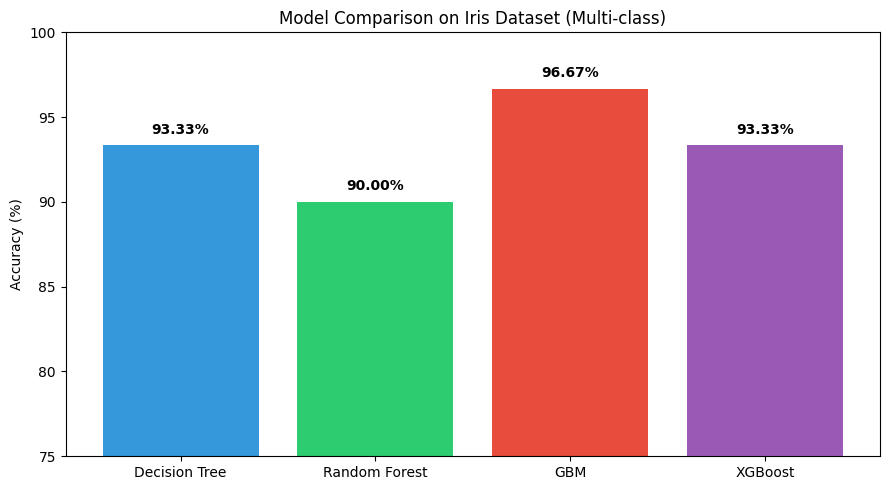


Iris Dataset Comparison:
        Model Accuracy
Decision Tree   93.33%
Random Forest   90.00%
          GBM   96.67%
      XGBoost   93.33%


In [10]:
# --- Compare all 4 methods on Iris ---
dt_i = DecisionTreeClassifier(random_state=42)
dt_i.fit(X_tr_i, y_tr_i)

rf_i = RandomForestClassifier(n_estimators=100, random_state=42)
rf_i.fit(X_tr_i, y_tr_i)

gbm_i = GradientBoostingClassifier(n_estimators=100, random_state=42)
gbm_i.fit(X_tr_i, y_tr_i)

acc_dt_i = accuracy_score(y_te_i, dt_i.predict(X_te_i))
acc_rf_i = accuracy_score(y_te_i, rf_i.predict(X_te_i))
acc_gbm_i = accuracy_score(y_te_i, gbm_i.predict(X_te_i))
acc_xgb_i = accuracy_score(y_te_i, y_pred_xgb)

models_i = ['Decision Tree', 'Random Forest', 'GBM', 'XGBoost']
accs_i = [acc_dt_i, acc_rf_i, acc_gbm_i, acc_xgb_i]

plt.figure(figsize=(9, 5))
colors_i = ['#3498db', '#2ecc71', '#e74c3c', '#9b59b6']
bars = plt.bar(models_i, [a * 100 for a in accs_i], color=colors_i)
plt.ylabel("Accuracy (%)")
plt.title("Model Comparison on Iris Dataset (Multi-class)")
plt.ylim(75, 100)

for bar, acc in zip(bars, accs_i):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
             f'{acc*100:.2f}%', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

print("\nIris Dataset Comparison:")
comp_i = pd.DataFrame({'Model': models_i, 'Accuracy': [f'{a*100:.2f}%' for a in accs_i]})
print(comp_i.to_string(index=False))

---
### 7. XGBoost Feature Importance

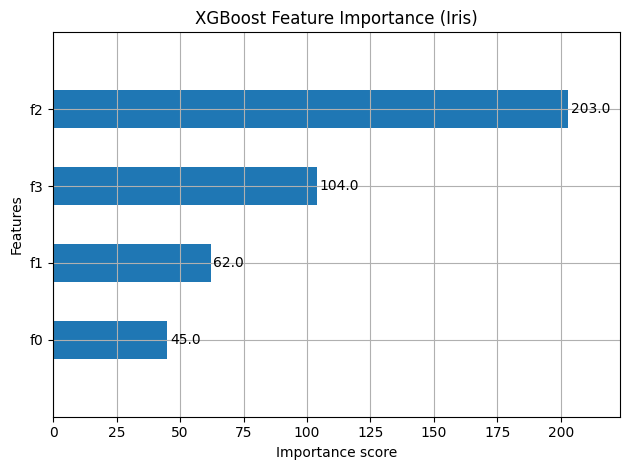

In [11]:
# XGBoost Feature Importance
xgb.plot_importance(bst, height=0.5)
plt.title("XGBoost Feature Importance (Iris)")
plt.tight_layout()
plt.show()

## Summary of Tree-Based Methods

| Method | Breast Cancer (Binary) | Iris (Multi-class) | Key Characteristics |
|--------|----------------------|-------------------|---------------------|
| Decision Tree | 94.74% | 93.33% | Simple, interpretable, prone to overfitting |
| Random Forest | 96.49% | 90.00% | Robust ensemble, handles high-dim data |
| GBM | 95.61% | 96.67% | Sequential boosting, high accuracy, slow to train |
| XGBoost | — | 93.33% | Optimized GBM, fast, regularized, scalable |

### Key Takeaways:
1. **Decision Trees** are easy to interpret but often overfit — use ensemble methods for better generalization.
2. **Random Forests** average many trees to reduce variance and improve stability.
3. **GBM** builds trees sequentially to correct errors, often achieving higher accuracy but with more hyperparameters to tune.
4. **XGBoost** is an optimized, production-ready GBM implementation with built-in regularization and faster training.

---
## Exercises

**Exercise 1:** Try changing `n_estimators` in Random Forest and GBM. How does accuracy change?

**Exercise 2:** Tune `max_depth` for the Decision Tree. What happens when depth = 10?

**Exercise 3:** Add `reg_lambda` and `reg_alpha` parameters to XGBoost. Does accuracy improve?

**Exercise 4:** Use `cross_val_score` with 5-fold CV to get a more robust accuracy estimate for each method.

**Exercise 5:** Apply all four models to the **Wine dataset** (`load_wine()`) and compare results.